<a href="https://colab.research.google.com/github/NicholasMaestrello/01_nicholas_git/blob/master/Pratica_Aula7_Correlacao.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SCC-ICMC-USP
# CURSO 2 - CD_AM_MD
## Exemplo 2

### **Profa. Roseli A. F. Romero**

#**OBJETIVOS**:
# Correlação, Covariância e visualização


...


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt



In [ ]:
iris = pd.read_csv('/content/drive/My Drive/iris_modif_novo.data', index_col=0)
iris

,A,B,C,D,E,F
0,4.9,3.0,1.4,30.0,0.2,Iris-setosa
1,4.7,3.2,1.3,32.0,0.2,Iris-setosa
2,4.6,3.1,1.5,31.0,0.2,Iris-setosa
3,5.0,3.6,1.4,36.0,0.2,Iris-setosa
4,5.4,3.9,1.7,39.0,0.4,Iris-setosa
...,...,...,...,...,...,...
144,6.7,3.0,5.2,30.0,2.3,Iris-virginica
145,6.3,2.5,5.0,25.0,1.9,Iris-virginica
146,6.5,3.0,5.2,30.0,2.0,Iris-virginica
147,6.2,3.4,5.4,34.0,2.3,Iris-virginica


In [ ]:
iris.info()

<class 'pandas.core.frame.DataFrame'>
Index: 159 entries, 0 to 148
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   A       159 non-null    float64
 1   B       159 non-null    float64
 2   C       159 non-null    float64
 3   D       159 non-null    float64
 4   E       159 non-null    float64
 5   F       159 non-null    object 
dtypes: float64(5), object(1)
memory usage: 8.7+ KB



## Vamos considerar neste exercicio o conjunto iris modificado

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### **Questão 01**.
##* Calcule a matriz de covariância (`np.cov`)
##* Crie um heatmap (`sns.heatmap`) para cada matriz
##* Dica: Atente-se ao atributo rowvar

In [ ]:

plt.rcParams['figure.figsize'] = [8, 6]

In [ ]:
# Cálculo da matriz de covariância
cov_matrix = np.cov(iris.drop(columns=["F"]), rowvar=False)


<Axes: >

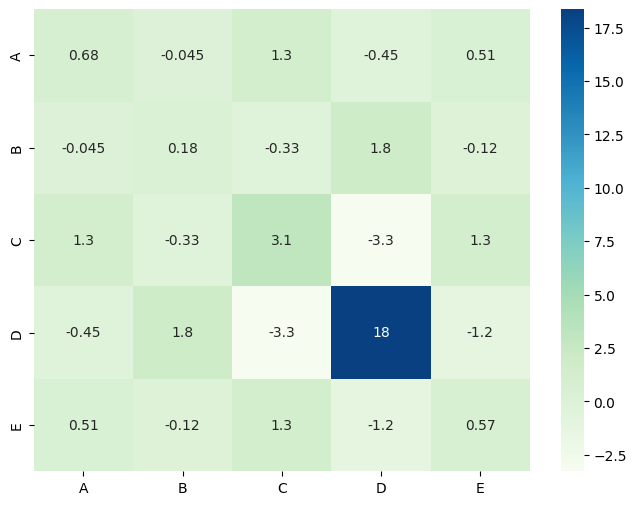

In [ ]:
# Gerando o mapa de calor da matriz de covariância
sns.heatmap(cov_matrix,
            annot=True,
            xticklabels=iris.columns[:-1],
            yticklabels=iris.columns[:-1],
            cmap="GnBu"
)

### **Questão 02**.

##Agora calcule a matriz de correlação (`pandas.DataFrame.corr` ou `np.corrcoef`) utilizando o método de Pearson, gerando um heatmap da matriz. Vamos desconsiderar a coluna 'F".

<Axes: >

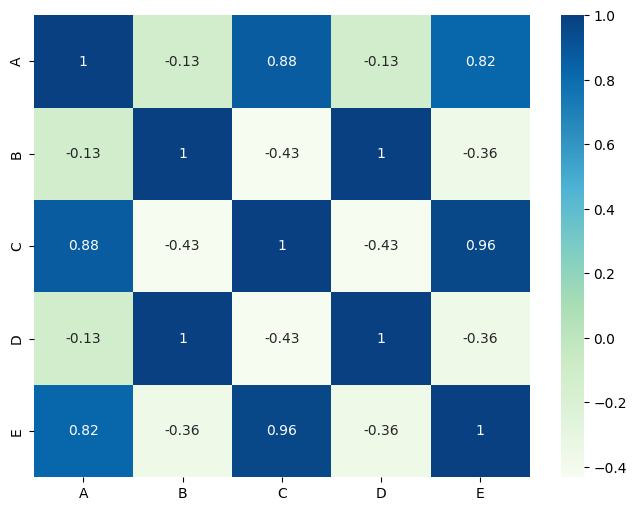

In [ ]:
sns.heatmap(iris.drop(columns=['F']).corr(),
            annot=True,
            cmap="GnBu"
)

### **Questão 03**.

##O método da Questão 2 apresenta alguma vantagem com relação ao método da Q1?

Resposta: Sim. A análise de covariância é sensível à escala dos valores analisados e este fato fica visível na observação do heatmap. Para a covariância, o valor da variância do atributo "D" se destaca bastante dos demais, prejudicando a análise dos demais atributos. Já a análise de correlação, por ter valores limitados entre -1 e 1 não apresenta o problema da covariância, e seu heatmap fica mais "uniforme". Na análise de correlação, como os valores estão normalizados é mais fácil identificar a "intensidade" das relações.

### **Questão 04**.

##  Utilizando o resultado da matriz de correlação, verifique se existe um atributo reduntante nessa base e crie um novo `Dataframe` sem ele e justifique.

Resposta: Observando a matriz de correlação, podemos observar que os atributos 'B' e 'D' possuem correlação máxima. Assim, podemos concluir que o atributo 'D', por exemplo, é redundante. Observando seus valores fica claro que os valores do atributo 'D' correspondem aos valores do atributo 'B' multiplicados por 10.

In [ ]:
iris_novo = iris.drop(columns=["D"])
iris_novo.head()

,A,B,C,E,F
0,4.9,3.0,1.4,0.2,Iris-setosa
1,4.7,3.2,1.3,0.2,Iris-setosa
2,4.6,3.1,1.5,0.2,Iris-setosa
3,5.0,3.6,1.4,0.2,Iris-setosa
4,5.4,3.9,1.7,0.4,Iris-setosa


### **Questão 05**.

##Agora calcule as matrizes de correlação utilizando os métodos de Kendall e Spearman. Exiba seus heatmaps.

<Axes: >

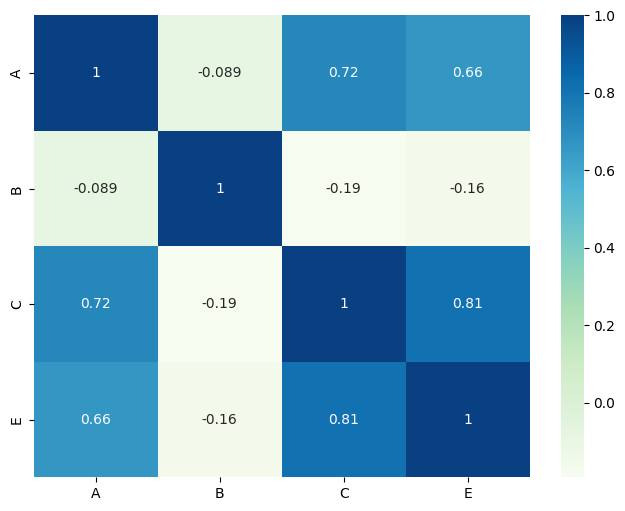

In [ ]:
# kendall
sns.heatmap(iris_novo.drop(columns=['F']).corr(method="kendall"),
            annot=True,
            cmap="GnBu"
)

<Axes: >

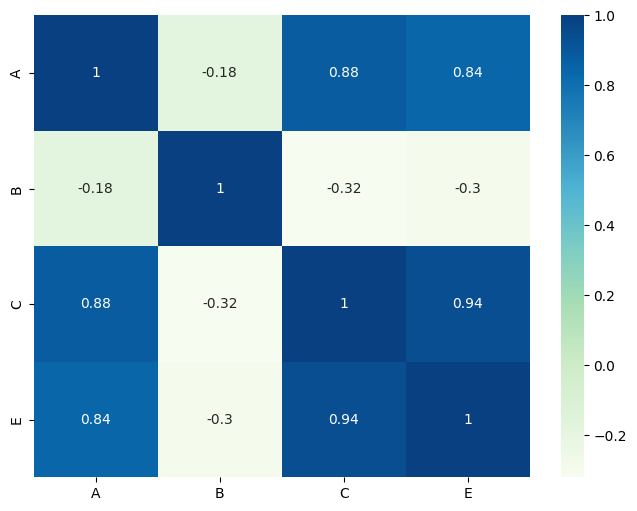

In [ ]:
# spearman
sns.heatmap(iris_novo.drop(columns=['F']).corr(method="spearman"),
            annot=True,
            cmap="GnBu"
)

### **Questão 06**.

##Determine os pares de variáveis que apresentam maior e menor correlação de spearman. Depois produza scatter plots (`matplotlib.pyplot.scatter`) desses pares de variáveis. Comente como os dados estão distribuídos nos gráficos.

In [ ]:
import matplotlib.pyplot as plt

Text(0.5, 1.0, 'Menor correlação')

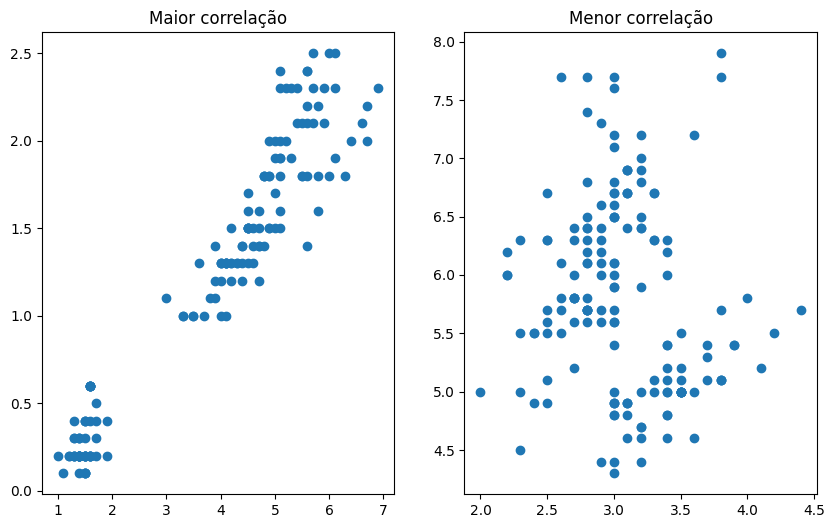

In [ ]:
# Através da matriz de correlação de Spearman, podemos observar que os atributos
# 'C' e 'E' possuem maior correlação enquanto que os 'B' e 'A'
# possuem menor correlação em módulo.

fig, axs = plt.subplots(1, 2, figsize=(10,6))
axs[0].scatter(iris_novo['C'], iris_novo['E'])
axs[0].set_title('Maior correlação')

axs[1].scatter(iris_novo['B'], iris_novo['A'])
axs[1].set_title('Menor correlação')


### Resposta: Considerando os gráficos obtidos, para os atributos com maior correlação a distribuição dos pontos segue uma reta. Por outro lado, para os atributos de menor módulo de correlação, a distribuição dos pontos fica mais esparsa.



 <!-- No gráfico dos atributos com maior correlação, a distribuição dos pontos se aproxima de uma reta de inclinação positiva, enquanto que no gráfico dos atributos com menor correlação a distribuição dos pontos é mais esparsa. Além disto, como a menor correlação é negativa a distribuição dos pontos se assemelha a uma reta de inclinação negativa. Com a análise das distribuições e dos valores de correlação, é possível identificar se há ou não uma dependência linear entre os atributos avaliados. -->

### **Questão 07**.

##Produza um diagrama de torta (`matplotlib.pyplot.pie`) mostrando a distribuição das 3 classes

In [ ]:
counts_df = iris["F"].value_counts()
counts_df

,count
F,
Iris-versicolor,56
Iris-virginica,54
Iris-setosa,49


([<matplotlib.patches.Wedge at 0x7c681df61ee0>,
 [Text(0.49259980877944665, 0.98353720234186, 'Iris-versicolor'),
  Text(-1.0894955528238104, -0.15165566384787585, 'Iris-virginica'),
  Text(0.6234949948266043, -0.9062306502354535, 'Iris-setosa')],
 [Text(0.26869080478878904, 0.5364748376410144, '35.22'),
  Text(-0.5942703015402602, -0.08272127118975046, '33.96'),
  Text(0.3400881789963296, -0.49430762740115636, '30.82')])

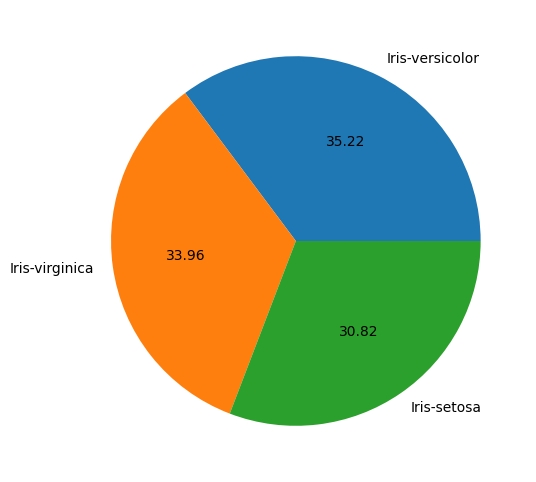

In [ ]:
plt.figure(figsize=(10, 6))
plt.pie(counts_df.values, labels=counts_df.index, autopct='%.2f')

### **Questão 08**.

##Produza um diagrama usando o UPSET mostrando a distribuição das 3 classes.
Para usar o UpSet os dados precisam ser binarios e transformados em valores booleanos: True ou False.

In [ ]:
!pip install upsetplot
from upsetplot import plot


In [ ]:
from upsetplot import plot

One_hot_df = pd.get_dummies(iris['F'], prefix='', prefix_sep='').astype(bool)
d = One_hot_df.value_counts()
d

Iris-setosa  Iris-versicolor  Iris-virginica
False        True             False             56
             False            True              54
True         False            False             49
Name: count, dtype: int64

/usr/local/lib/python3.12/dist-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inplace=True)
/usr/local/lib/python3.12/dist-packages/upsetplot/plotting.py:796: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example,

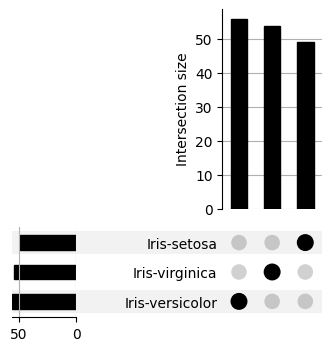

In [ ]:
plot(d, sort_by='cardinality')
plt.show()

/usr/local/lib/python3.12/dist-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inplace=True)
/usr/local/lib/python3.12/dist-packages/upsetplot/plotting.py:796: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example,

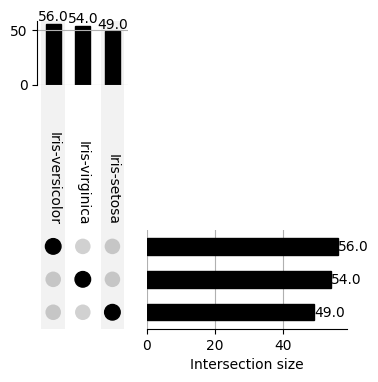

In [ ]:
plot(d, sort_by='cardinality', orientation = 'vertical', show_counts = '%.1f')
plt.show( )